In [1]:
!pip install nltk
!pip install Sastrawi
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 27.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

In [3]:
data_path = 'google.csv'
df = pd.read_csv(data_path)

In [4]:
df.sample(5)

,link berita,judul berita,media,tanggal posting
16,https://tasikmalayaku.id/konten-kekerasan-seks...,Konten Kekerasan Seksual Ferry Irwandi Tuai Ke...,Tasikmalaya Ku,5 hari yang lalu
75,https://sulteng.disway.id/news/read/1402/akade...,Akademisi Soroti Etika Publik dalam Narasi Fer...,Disway,5 hari yang lalu
49,https://www.sketsanusantara.id/news/1032017028...,Ferry Irwandi Geram Banyak Media Online yang S...,Sketsa Nusantara,5 hari yang lalu
43,https://www.beritasatu.com/nusantara/2947613/f...,Ferry Irwandi Tepis Fitnah Politisasi Derita K...,BeritaSatu.com,5 hari yang lalu
74,https://palembang.inews.id/read/657758/ketua-i...,Ketua IKPS Lubuk Linggau Sesalkan Narasi Ferry...,iNews.ID,6 hari yang lalu


In [5]:
# Mengecek jumlah row & coloumn
print(f'shape: {df.shape}')

shape: (81, 4)


**CLEANING DUPLICATE**

In [6]:
# Cek jumlah nilai duplikat di kolom 'akun'
duplicates = df['judul berita'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'judul berita': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'judul berita': 28

Contoh baris dengan nilai duplikat:
                                          link berita  \
3   https://jambiindependent.disway.id/metronews/r...   
9   https://www.beritasatu.com/nusantara/2947613/f...   
10  https://kabarnusa.com/pusdeham-institut-kecam-...   
11  https://siap.viva.co.id/news/21638-ketua-ikps-...   
13  https://www.beritasatu.com/network/kabarnusa/7...   
21  https://nasional.kompas.com/read/2025/12/09/21...   
22  https://indeksnews.com/narasi-horor-ferry-irwa...   
28  https://www.korankota.com/v151/t502/87649/dire...   
29  https://jambiindependent.disway.id/metronews/r...   
32  https://www.msn.com/id-id/berita/nasional/npi-...   

                                         judul berita             media   \
3   Ferry Irwandi Disorot Langgar Etika Publik ole...  Jambi Independent   
9   Ferry Irwandi Tepis Fitnah Politisasi Derita K...     BeritaSatu.com   
10       Pusdeham Institut Kecam Konten Ferry Irwa

In [7]:
# Baca data
df = pd.read_csv('google.csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['judul berita'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate berita.csv', index=False)

Sebelum: 81 baris
Sesudah: 66 baris
Jumlah duplikat dihapus: 15


**CLEANING TANGGAL**

In [8]:
import pandas as pd
from datetime import datetime, timedelta
import re

# Baca dataset
df = pd.read_csv('google.csv')  # ← pastikan file ini ada!

# Tanggal referensi: 13 Desember 2025
reference_datetime = datetime(2025, 12, 13)

def convert_relative_to_short_date(time_str):
    if pd.isna(time_str) or not isinstance(time_str, str):
        return 'Invalid Date'

    try:
        s = time_str.strip().lower()
        print(f"Processing: '{s}'")

        # Ekstrak angka dari string
        match = re.search(r'(\d+)', s)
        if not match:
            return 'Invalid Date'

        number = int(match.group(1))

        # Tentukan satuan: hari atau minggu
        if 'hari' in s:
            calculated = reference_datetime - timedelta(days=number)
        elif 'minggu' in s:
            calculated = reference_datetime - timedelta(weeks=number)
        else:
            return 'Invalid Date'

        # Format jadi '3 Des'
        return calculated.strftime('%d %b').lower()

    except Exception as e:
        print(f"Error converting '{time_str}': {e}")
        return 'Invalid Date'

# Terapkan ke kolom 'tanggal posting'
df['tanggal_posting_singkat'] = df['tanggal posting'].apply(convert_relative_to_short_date)

# Simpan hasil
df.to_csv('google_tanggal_diperbaiki.csv', index=False)

# Tampilkan hasil
print("Sample of converted data:")
print(df[['tanggal posting', 'tanggal_posting_singkat']].head(10))

Processing: '5 hari yang lalu'
Processing: '3 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '4 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '6 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '4 hari yang lalu'
Processing: '6 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '3 hari yang lalu'
Processing: '3 hari yang lalu'
Processing: '4 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '4 hari yang lalu'
Processing: '7 hari yang lalu'
Processing: '2 hari yang lalu'
Processing: '4 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '6 hari yang lalu'
Processing: '5 hari yang lalu'
Processing: '6 hari yang lalu'
Processing: '6 hari yang lalu'
Processi

In [11]:
import pandas as pd

# Baca dataset
df = pd.read_csv('google_tanggal_diperbaiki.csv')  # ← ganti dengan nama file-mu

# Hitung jumlah per tanggal
tanggal_counts = df['tanggal_posting_singkat'].value_counts()

# Urutkan berdasarkan tanggal (opsional, tapi berguna)
# Karena format '08 des', kita perlu urutkan manual berdasarkan urutan bulan
bulan_order = ['jan', 'feb', 'mar', 'apr', 'mei', 'jun', 'jul', 'agu', 'sep', 'okt', 'nov', 'des']

# Ekstrak bulan dan hari untuk urutkan
def extract_sort_key(date_str):
    try:
        day, month = date_str.split()
        return (bulan_order.index(month), int(day))
    except:
        return (999, 999)  # nilai akhir untuk yang error

# Urutkan DataFrame
tanggal_df = tanggal_counts.reset_index()
tanggal_df.columns = ['tanggal_posting_singkat', 'jumlah']
tanggal_df = tanggal_df.sort_values(
    by='tanggal_posting_singkat',
    key=lambda x: [extract_sort_key(d) for d in x]
).reset_index(drop=True)

# Tampilkan hasil
print("Jumlah Posting per Tanggal:")
print("=" * 40)
print(tanggal_df)

# Simpan ke file (opsional)
tanggal_df.to_csv('jumlah_per_tanggal.csv', index=False)

Jumlah Posting per Tanggal:
  tanggal_posting_singkat  jumlah
0                  08 dec      50
1                  07 dec      13
2                  09 dec      11
3                  10 dec       5
4                  06 dec       1
5                  11 dec       1


**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [12]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_judul'] = df['judul berita'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
                                         link berita  \
0  https://www.inilah.com/disebut-sebar-hoaks-pel...   
1  https://mediapakuan.pikiran-rakyat.com/sosok/p...   
2  https://m.jpnn.com/news/pakar-nilai-narasi-fer...   
3  https://jambiindependent.disway.id/metronews/r...   
4  https://suarapembaruan.net/2025/12/08/gampi-se...   

                                        judul berita              media   \
0  Disebut Sebar Hoaks Pelecehan di Lokasi Bencan...          Inilah.com   
1  Etika Komunikasi Publik di Tengah Bencana, Nar...        Media Pakuan   
2  Pakar Nilai Narasi Ferry Irwandi Melanggar Eti...            JPNN.com   
3  Ferry Irwandi Disorot Langgar Etika Publik ole...   Jambi Independent   
4  GAMPI Sesalkan Pernyataan Ferry Irwandi Terkai...  suarapembaruan.net   

    tanggal posting tanggal_posting_singkat  \
0  5 hari yang lalu                  08 dec   
1  3 hari yang lalu                  10 dec   
2  5 hari yang lalu                  0

**MENGHAPUS STOPWORDS**

In [13]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_judul'] = df['cleaned_judul'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Data Setelah Penghapusan Stop Words:
                                         link berita  \
0  https://www.inilah.com/disebut-sebar-hoaks-pel...   
1  https://mediapakuan.pikiran-rakyat.com/sosok/p...   
2  https://m.jpnn.com/news/pakar-nilai-narasi-fer...   
3  https://jambiindependent.disway.id/metronews/r...   
4  https://suarapembaruan.net/2025/12/08/gampi-se...   

                                        judul berita              media   \
0  Disebut Sebar Hoaks Pelecehan di Lokasi Bencan...          Inilah.com   
1  Etika Komunikasi Publik di Tengah Bencana, Nar...        Media Pakuan   
2  Pakar Nilai Narasi Ferry Irwandi Melanggar Eti...            JPNN.com   
3  Ferry Irwandi Disorot Langgar Etika Publik ole...   Jambi Independent   
4  GAMPI Sesalkan Pernyataan Ferry Irwandi Terkai...  suarapembaruan.net   

    tanggal posting tanggal_posting_singkat  \
0  5 hari yang lalu                  08 dec   
1  3 hari yang lalu                  10 dec   
2  5 hari yang lalu        

**STEMMING DATA**

In [14]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_judul'] = df['cleaned_judul'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
                                         link berita  \
0  https://www.inilah.com/disebut-sebar-hoaks-pel...   
1  https://mediapakuan.pikiran-rakyat.com/sosok/p...   
2  https://m.jpnn.com/news/pakar-nilai-narasi-fer...   
3  https://jambiindependent.disway.id/metronews/r...   
4  https://suarapembaruan.net/2025/12/08/gampi-se...   

                                        judul berita              media   \
0  Disebut Sebar Hoaks Pelecehan di Lokasi Bencan...          Inilah.com   
1  Etika Komunikasi Publik di Tengah Bencana, Nar...        Media Pakuan   
2  Pakar Nilai Narasi Ferry Irwandi Melanggar Eti...            JPNN.com   
3  Ferry Irwandi Disorot Langgar Etika Publik ole...   Jambi Independent   
4  GAMPI Sesalkan Pernyataan Ferry Irwandi Terkai...  suarapembaruan.net   

    tanggal posting tanggal_posting_singkat  \
0  5 hari yang lalu                  08 dec   
1  3 hari yang lalu                  10 dec   
2  5 hari yang lalu                  08 d

**TOKENIZATION**

In [15]:
# Tokenisasi
df['tokens'] = df['stemmed_judul'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean2.csv', index=False)


Data Setelah Tokenisasi:
                                         link berita  \
0  https://www.inilah.com/disebut-sebar-hoaks-pel...   
1  https://mediapakuan.pikiran-rakyat.com/sosok/p...   
2  https://m.jpnn.com/news/pakar-nilai-narasi-fer...   
3  https://jambiindependent.disway.id/metronews/r...   
4  https://suarapembaruan.net/2025/12/08/gampi-se...   

                                        judul berita              media   \
0  Disebut Sebar Hoaks Pelecehan di Lokasi Bencan...          Inilah.com   
1  Etika Komunikasi Publik di Tengah Bencana, Nar...        Media Pakuan   
2  Pakar Nilai Narasi Ferry Irwandi Melanggar Eti...            JPNN.com   
3  Ferry Irwandi Disorot Langgar Etika Publik ole...   Jambi Independent   
4  GAMPI Sesalkan Pernyataan Ferry Irwandi Terkai...  suarapembaruan.net   

    tanggal posting tanggal_posting_singkat  \
0  5 hari yang lalu                  08 dec   
1  3 hari yang lalu                  10 dec   
2  5 hari yang lalu                  08

**BERSIHKAN DATA YG MASIH BELUM RAPI**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   link berita              81 non-null     object
 1   judul berita             81 non-null     object
 2   media                    81 non-null     object
 3   tanggal posting          81 non-null     object
 4   tanggal_posting_singkat  81 non-null     object
 5   cleaned_judul            81 non-null     object
 6   stemmed_judul            81 non-null     object
 7   tokens                   81 non-null     object
dtypes: object(8)
memory usage: 5.2+ KB


**BUAT VISUALISASI WORLDCLOUD**

In [17]:
from wordcloud import STOPWORDS

# Tambahkan kata khusus Indonesia yang mungkin tidak ada di daftar bawaan
stop_words = set(STOPWORDS)
stop_words.update(['yg', 'nya', 'dgn', 'ya', 'trs', 'jg', 'kalo', 'gw', 'lu', 'gue', 'lo', 'nih', 'mah', 'sih', 'krn', 'karena'])

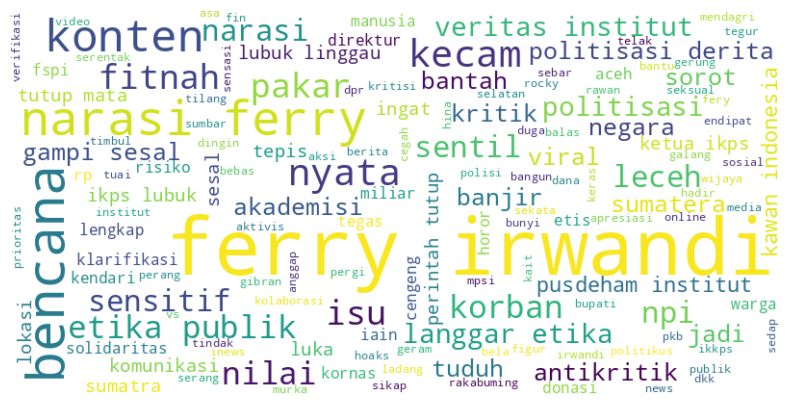

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data dari file CSV
df = pd.read_csv('processed_clean2.csv')  # Ganti 'path_to_your_file.csv' dengan jalur file data Anda

# Gabungkan semua teks dalam kolom 'cleaned_komen' menjadi satu string besar
text = " ".join(judul for judul in df['stemmed_judul'].dropna())  # Pastikan tidak ada nilai NaN



# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

**VISUALISASI KATA KUNCI TERBANYAK (WORDCLOUD)**

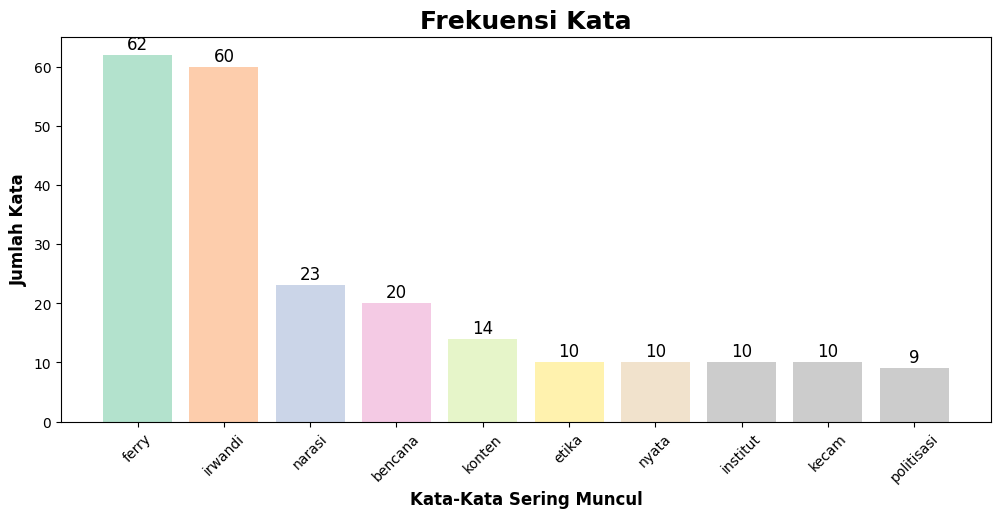

In [19]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = " ".join(judul for judul in df['stemmed_judul'].dropna())


tokens = [word for word in text.split() if word not in stop_words]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel2(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

**TAMPILKAN NAMA NAMA MEDIA**

In [25]:
import pandas as pd

# Baca file CSV (ganti dengan nama file-mu)
df = pd.read_csv('google.csv')

# Tampilkan semua nama kolom
print("Nama kolom yang tersedia:")
print(df.columns.tolist())

Nama kolom yang tersedia:
['link berita', 'judul berita', 'media ', 'tanggal posting']


In [31]:
import pandas as pd

# Baca dataset
df = pd.read_csv('google.csv')  # ← ganti dengan nama file-mu

# Hitung jumlah unik per media
media_counts = df['media '].value_counts()

# Tampilkan hasil
print("Daftar Media Berita dan Jumlah Kemunculannya:")
print("=" * 50)
print(media_counts)

media_counts.to_csv('jumlah_media_berita_rapi.csv', index=False)

Daftar Media Berita dan Jumlah Kemunculannya:
media 
kabarnusa.com            7
iNews.ID                 5
JPNN.com                 5
BeritaSatu.com           4
Media Pakuan             3
Kompas.com               3
Disway                   3
Lintas Parlemen          3
KoranKota                3
SinPo.id                 3
news.fin.co.id           2
Jambi Independent        2
suarapembaruan.net       2
Indeks News              2
Rmol.id                  2
MSN                      2
VIVA Siap                2
Sinarharapan.id          1
rmolsumsel               1
Inilah.com               1
Gemapos                  1
rilisid tv               1
VOI.ID                   1
BandaSapuluah            1
desusin.com              1
VIVA.co.id               1
Suara Merdeka Jakarta    1
Tasikmalaya Ku           1
Detak Patria News        1
detiksatu.com            1
trenmedia.co.id          1
MPN Indonesia            1
Sekitar Bandung          1
Indopop.id               1
Oposisi Cerdas           1
pa

In [34]:
import pandas as pd

# Baca dataset (ganti nama file sesuai punyamu)
df = pd.read_csv('google.csv')  # ← GANTI DENGAN NAMA FILE-MU

# Hapus baris yang kosong atau NaN di kolom 'media'
df = df.dropna(subset=['media '])
df = df[df['media '].str.strip() != '']

# Hitung jumlah per media (unik + frekuensi)
media_counts = df['media '].value_counts().reset_index()

# Beri nama kolom yang jelas
media_counts.columns = ['media ', 'jumlah']

# Urutkan dari yang paling sering muncul
media_counts = media_counts.sort_values('jumlah', ascending=False).reset_index(drop=True)

# Simpan ke file CSV baru
media_counts.to_csv('jumlah_media_berita.csv', index=False)

# Tampilkan pesan sukses
print("✅ File berhasil disimpan sebagai: 'jumlah_media_berita.csv'")
print("\nContoh isi file:")
print(media_counts.head(10))

✅ File berhasil disimpan sebagai: 'jumlah_media_berita.csv'

Contoh isi file:
            media   jumlah
0    kabarnusa.com       7
1         iNews.ID       5
2         JPNN.com       5
3   BeritaSatu.com       4
4     Media Pakuan       3
5       Kompas.com       3
6           Disway       3
7  Lintas Parlemen       3
8        KoranKota       3
9         SinPo.id       3
